In [15]:
import pandas as pd
import numpy as np
police = pd.read_csv('police.csv')


In [16]:
police['outcome_description']

0        No arrest made or summons issued
1         Moving violation summons issued
2         Moving violation summons issued
3        No arrest made or summons issued
4          Arrest - other violation/crime
                       ...               
33353     Moving violation summons issued
33354     Moving violation summons issued
33355     Moving violation summons issued
33356     Moving violation summons issued
33357     Moving violation summons issued
Name: outcome_description, Length: 33358, dtype: object

In [17]:
police.columns

Index(['unique_mos_id', 'first_name', 'last_name', 'command_now', 'shield_no',
       'complaint_id', 'month_received', 'year_received', 'month_closed',
       'year_closed', 'command_at_incident', 'rank_abbrev_incident',
       'rank_abbrev_now', 'rank_now', 'rank_incident', 'mos_ethnicity',
       'mos_gender', 'mos_age_incident', 'complainant_ethnicity',
       'complainant_gender', 'complainant_age_incident', 'fado_type',
       'allegation', 'precinct', 'contact_reason', 'outcome_description',
       'board_disposition'],
      dtype='object')

In [18]:
police['year_received'].sort_values(ascending=False).head(10)

32429    2020
14535    2020
14534    2020
14533    2020
29964    2019
23218    2019
29963    2019
29962    2019
29961    2019
29960    2019
Name: year_received, dtype: int64

/var/folders/_5/l3pcb2dd2z1c25f6tlf6dgc40000gn/T/ipykernel_59248/455872083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_analysis['date'] = pd.to_datetime(time_analysis['year_received'].astype(str) + '-' + time_analysis['month_received'].astype(str) + '-01')


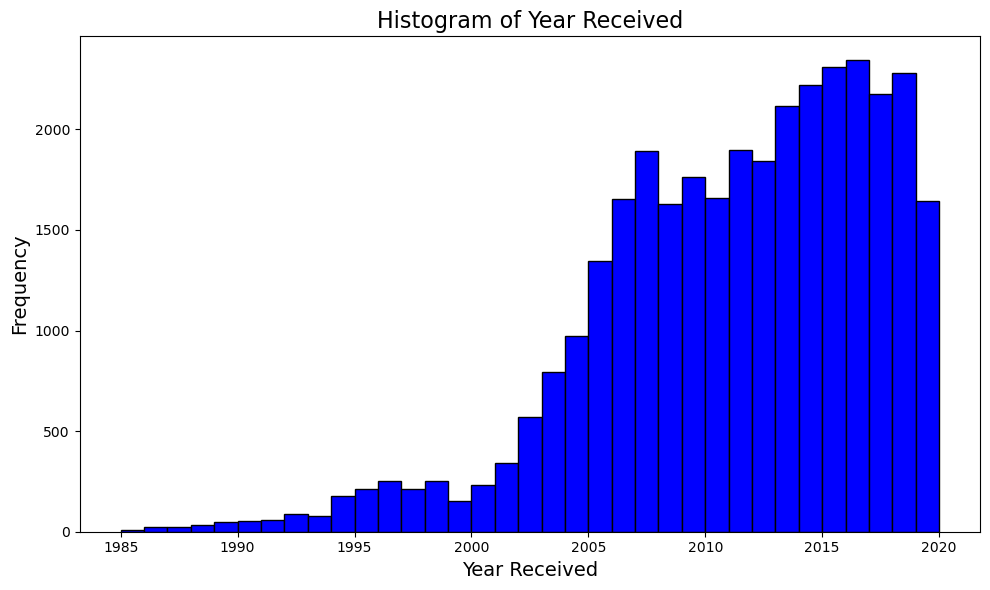

In [19]:
time_analysis = police[['month_received', 'year_received', 'complaint_id']]

time_analysis['date'] = pd.to_datetime(time_analysis['year_received'].astype(str) + '-' + time_analysis['month_received'].astype(str) + '-01')

time_analysis = time_analysis[['year_received', 'complaint_id']]

time_analysis.groupby('year_received').size()

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.hist(police['year_received'], bins= 2020-1985, color='blue', edgecolor='black')

# Add labels and title
plt.title('Histogram of Year Received', fontsize=16)
plt.xlabel('Year Received', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()




In [51]:
police['fado_type'].unique()

array(['Abuse of Authority', 'Discourtesy', 'Offensive Language', 'Force'],
      dtype=object)

In [175]:
police.groupby('year_received').size()

year_received
1985       7
1986      22
1987      22
1988      35
1989      49
1990      54
1991      56
1992      88
1993      76
1994     177
1995     213
1996     254
1997     214
1998     250
1999     155
2000     232
2001     344
2002     571
2003     792
2004     972
2005    1345
2006    1654
2007    1892
2008    1631
2009    1761
2010    1659
2011    1896
2012    1841
2013    2114
2014    2220
2015    2312
2016    2345
2017    2178
2018    2281
2019    1642
2020       4
dtype: int64

In [173]:
police['fado_type'].value_counts()

fado_type
Abuse of Authority    20292
Force                  7636
Discourtesy            4677
Offensive Language      753
Name: count, dtype: int64

In [73]:
police['action_taken'] = police['outcome_description'].apply(lambda x: x != 'No arrest made or summons issued')

police.rename(columns={'mos_ethnicity': 'officer_ethnicity'}, inplace=True)

police['force'] = police['fado_type'].apply(lambda x: x == 'Force')

police['Hispanic'] = police['complainant_ethnicity'].apply(lambda x: x == 'Hispanic')


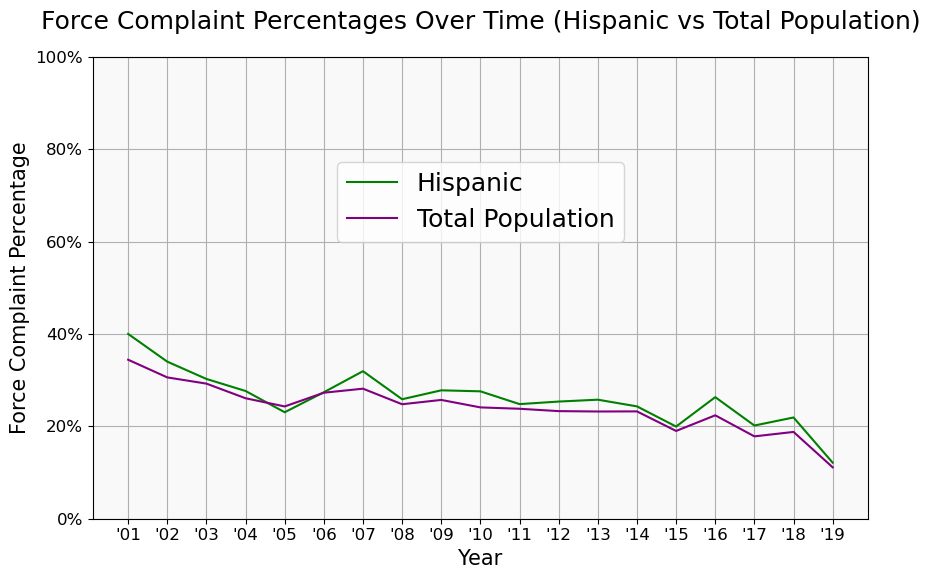

In [177]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming police is your original DataFrame
by_year = pd.DataFrame(police.groupby(['Hispanic', 'year_received'])['force'].mean())
by_year = by_year.reset_index()

# Filter for years between 2001 and 2019
by_year = by_year[(by_year['year_received'] > 2000) & (by_year['year_received'] <= 2019)]

df = by_year

# Step 1: Separate the true group
true_group = df[df['Hispanic'] == True]

# Step 2: Group the combined data by year and average force
combined_group = df.groupby('year_received', as_index=False)['force'].mean()

# Convert year_received to numeric
df['year_received'] = pd.to_numeric(df['year_received'])

# Step 3: Increase figure size
plt.figure(figsize=(10, 6))  # Adjust width (10) and height (6) as needed

# Plot
plt.plot(true_group['year_received'], true_group['force'], label='Hispanic', color='green')
plt.plot(combined_group['year_received'], combined_group['force'], label='Total Population', color='purple')

# Set xticks to show each year
years = range(2001, 2020)
year_labels = [f'\'{str(y)[-2:]}' for y in years]  # Convert 2001 → '01', etc.
plt.xticks(years, year_labels, fontsize=12)
  # This will display each year from 2001 to 2019 on the x-axis

# Modify the y-tick labels
# Example: Show ticks from 0 to 1 with a step of 0.1 and set custom labels
y_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
y_labels = ['0%', '20%', '40%', '60%', '80%', '100%']  # Custom labels for ticks

plt.yticks(y_ticks, y_labels, fontsize = 12)  # Set the custom y-tick labels

# Labels and Title
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Force Complaint Percentage', fontsize = 15)
plt.title('Force Complaint Percentages Over Time (Hispanic vs Total Population)', fontsize = 18, pad = 20)

plt.gca().set_facecolor('#f9f9f9')
# Move the legend to the upper middle
plt.legend(loc='upper center', bbox_to_anchor=(0.5, .8), fontsize=18)  # loc='upper center' for middle top, bbox_to_anchor for fine tuning

plt.grid(True)

# Show the plot
plt.show()


In [156]:
# Merge the two datasets on year to align values
merged = pd.merge(true_group, combined_group, on='year_received', suffixes=('_hispanic', '_all'))

# Calculate the difference each year
merged['difference'] = merged['force_hispanic'] - merged['force_all']

# Compute the average difference
average_difference = merged['difference'].mean()

# Print the result as a percentage
print(f"Average difference (Hispanic - All) from 2001 to 2019: {average_difference:.4f} ({average_difference:.2%})")


Average difference (Hispanic - All) from 2001 to 2019: 0.0205 (2.05%)


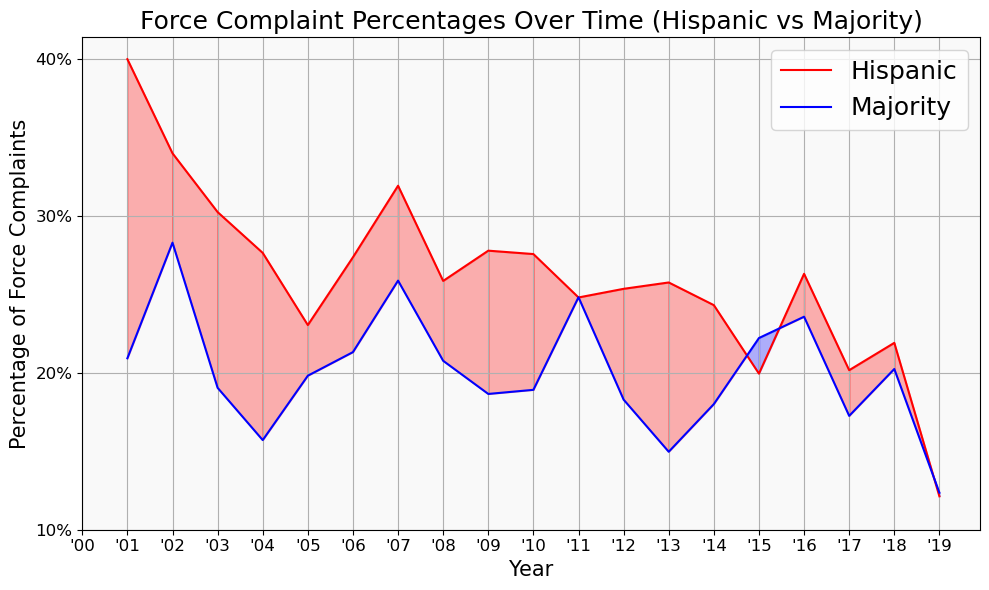

In [171]:
import matplotlib.pyplot as plt
import pandas as pd

ran = [2000, 2019]

# Assuming your DataFrame is named police
by_year = pd.DataFrame(police.groupby(['complainant_ethnicity', 'year_received'])['force'].mean()).reset_index()
by_year = by_year[by_year['complainant_ethnicity'].isin(['Hispanic', 'White'])]
by_year = by_year[(by_year['year_received'] > ran[0]) & (by_year['year_received'] <= ran[1])]
df = by_year.copy()

# Ensure year is numeric
df['year_received'] = pd.to_numeric(df['year_received'])

# Separate data
hispanic_data = df[df['complainant_ethnicity'] == 'Hispanic'].sort_values('year_received')
white_data = df[df['complainant_ethnicity'] == 'White'].sort_values('year_received')

x = hispanic_data['year_received'].values
y1 = hispanic_data['force'].values
y2 = white_data['force'].values

# Plot setup
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Hispanic', color='red')
plt.plot(x, y2, label='Majority', color='blue')

# Fill between logic (same as before)
for i in range(1, len(x)):
    x_vals = [x[i-1], x[i]]
    y1_vals = [y1[i-1], y1[i]]
    y2_vals = [y2[i-1], y2[i]]

    if (y1_vals[0] - y2_vals[0]) * (y1_vals[1] - y2_vals[1]) < 0:
        dx = x_vals[1] - x_vals[0]
        dy1 = y1_vals[1] - y1_vals[0]
        dy2 = y2_vals[1] - y2_vals[0]
        slope_diff = dy1 - dy2
        if slope_diff != 0:
            t = (y2_vals[0] - y1_vals[0]) / slope_diff
            x_cross = x_vals[0] + t * dx
            y_cross = y1_vals[0] + t * dy1

            plt.fill_between([x_vals[0], x_cross], [y1_vals[0], y_cross], [y2_vals[0], y_cross],
                             color='red' if y1_vals[0] > y2_vals[0] else 'blue', alpha=0.3)
            plt.fill_between([x_cross, x_vals[1]], [y_cross, y1_vals[1]], [y_cross, y2_vals[1]],
                             color='red' if y1_vals[1] > y2_vals[1] else 'blue', alpha=0.3)
    else:
        plt.fill_between(x_vals, y1_vals, y2_vals,
                         color='red' if y1_vals[0] > y2_vals[0] else 'blue', alpha=0.3)

# Formatting to match second plot

# Light background
plt.gca().set_facecolor('#f9f9f9')

# X-axis ticks and labels
years = range(ran[0], ran[1] + 1)
year_labels = [f'\'{str(y)[-2:]}' for y in years]
plt.xticks(years, year_labels, fontsize=12)

# Y-axis ticks and labels
y_ticks = [0.1, 0.2, 0.3, 0.4]
y_labels = ['10%', '20%', '30%', '40%']
plt.yticks(y_ticks, y_labels, fontsize=12)

# Labels and title
plt.xlabel('Year', fontsize=15)
plt.ylabel('Percentage of Force Complaints', fontsize=15)
plt.title('Force Complaint Percentages Over Time (Hispanic vs Majority)', fontsize=18)

# Legend
plt.legend(loc='upper right', fontsize=18)

# Grid and layout
plt.grid(True)
plt.tight_layout()

# Show plot
plt.show()


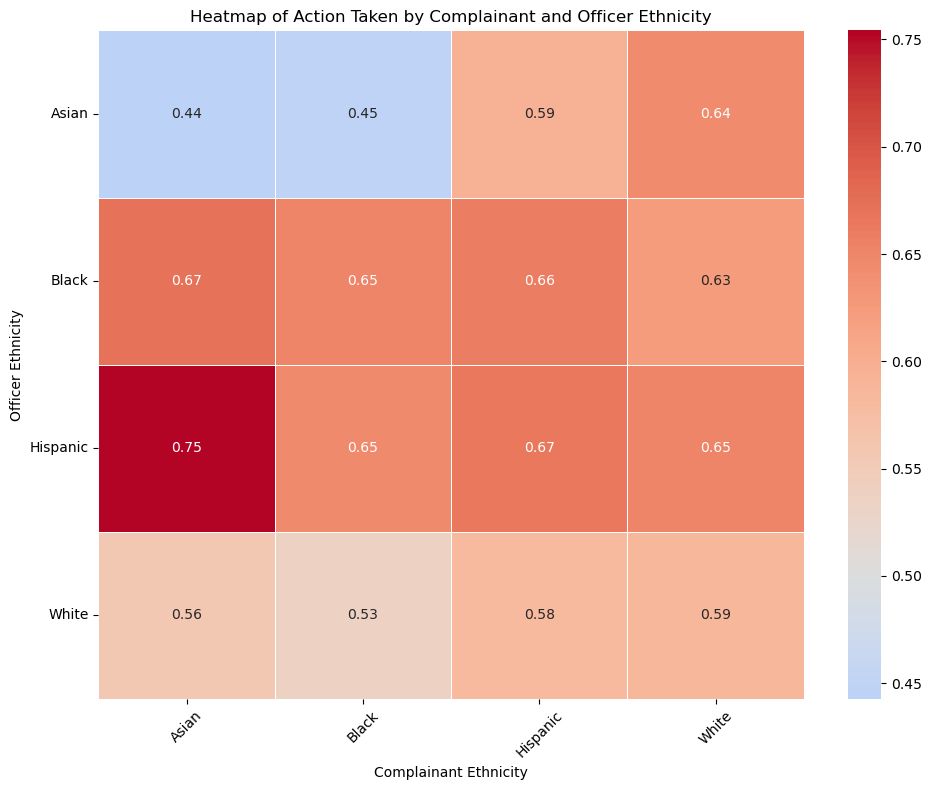

In [21]:
police[['complainant_ethnicity', 'mos_ethnicity', 'action_taken']]

need = police.groupby(['complainant_ethnicity', 'mos_ethnicity'])['action_taken'].mean()


import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame called df
# If it's a MultiIndex like you posted, you can reset the index:
df = need.reset_index()

df.rename(columns={'mos_ethnicity': 'officer_ethnicity'}, inplace=True)

eths = ['Asian', 'Black', 'Hispanic', 'White']

df = df[df['complainant_ethnicity'].isin(eths) & df['officer_ethnicity'].isin(eths)]

# Pivot the data for the heatmap
heatmap_data = df.pivot(index='complainant_ethnicity', columns='officer_ethnicity', values='action_taken')

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0.5, linewidths=0.5)

# Styling
plt.title('Heatmap of Action Taken by Complainant and Officer Ethnicity')
plt.xlabel('Complainant Ethnicity')
plt.ylabel('Officer Ethnicity')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


In [17]:
df

,complainant_ethnicity,mean_action_taken
1,Asian,0.590226
2,Black,0.640937
3,Hispanic,0.659247
7,White,0.577075


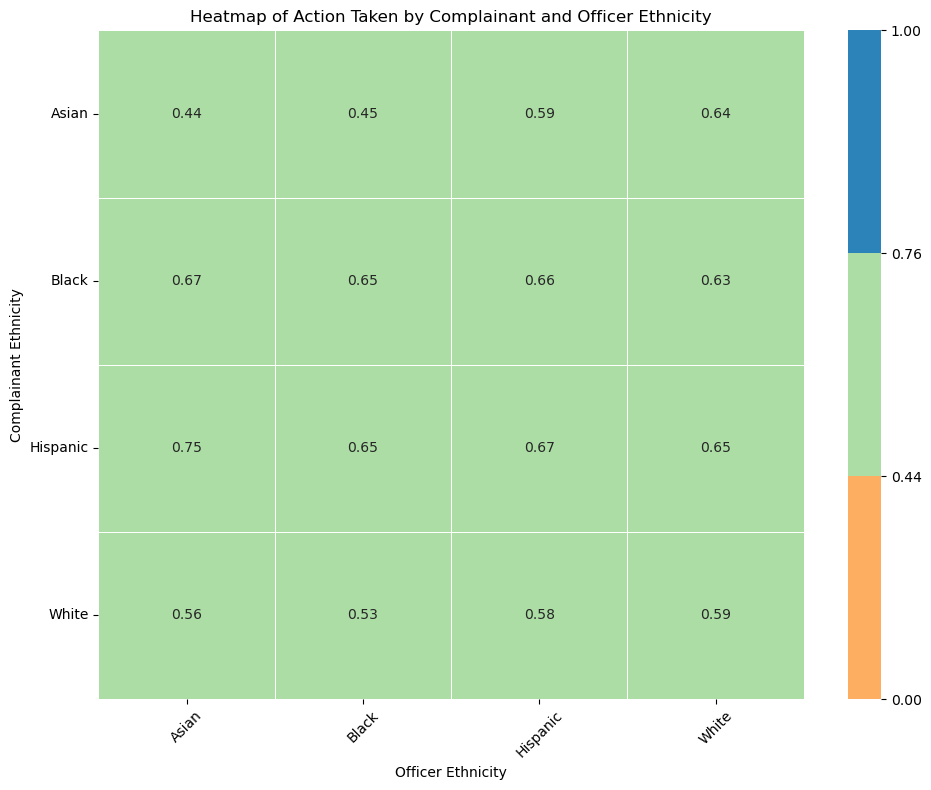

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# Example DataFrame (your `heatmap_data` should be here)
# Replace this with your actual data
# heatmap_data = your pivoted dataframe here

# 1. Define value ranges and corresponding colors
bounds = [0,0.44, 0.76, 1.0]
colors = ['#fdae61', '#abdda4', '#2b83ba']

# 2. Create colormap and normalizer
cmap = ListedColormap(colors)  # This must be an *instance*, not the class
norm = BoundaryNorm(bounds, ncolors=cmap.N)

# 3. Plot heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    norm=norm,
    linewidths=0.5,
    cbar_kws={'ticks': bounds}
)

# 4. Label formatting
plt.title('Heatmap of Action Taken by Complainant and Officer Ethnicity')
plt.xlabel('Officer Ethnicity')
plt.ylabel('Complainant Ethnicity')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [41]:
police.groupby('complainant_ethnicity').size()

complainant_ethnicity
American Indian       64
Asian                532
Black              17114
Hispanic            6424
Other Race           677
Refused              259
Unknown             1041
White               2783
dtype: int64

In [40]:
police_sub = police[police['allegation'] == 'Physical force']

police_sub.groupby('complainant_ethnicity').size()

complainant_ethnicity
American Indian       4
Asian                69
Black              2815
Hispanic           1121
Other Race           94
Refused              30
Unknown             205
White               416
dtype: int64

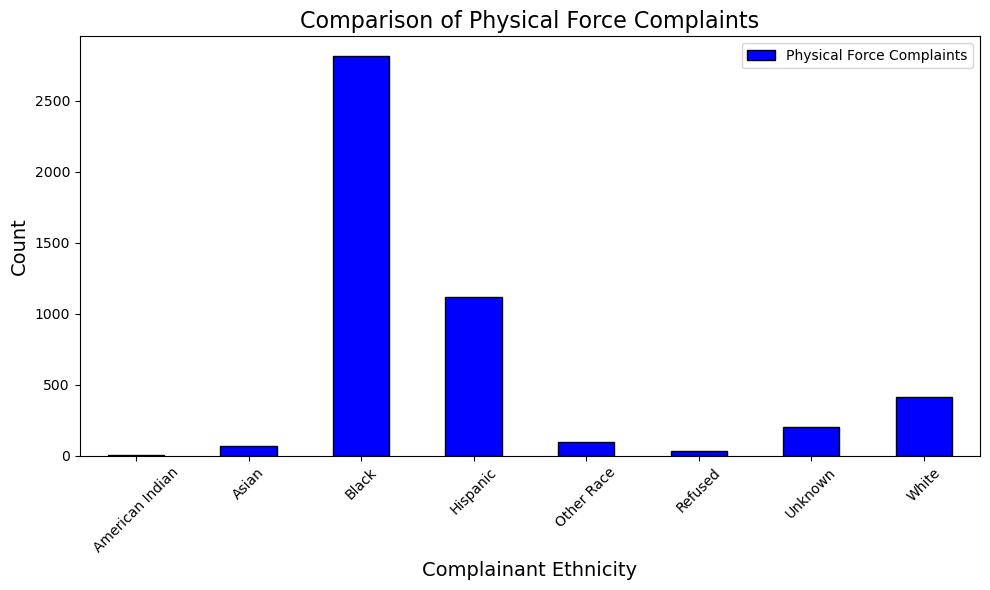

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the total counts by complainant ethnicity
total_counts = police.groupby('complainant_ethnicity').size()

# Calculate the counts for 'Physical force' allegations by complainant ethnicity
physical_force_counts = police_sub.groupby('complainant_ethnicity').size()

# Combine the two series into a DataFrame for comparison
comparison_df = pd.DataFrame({
    #'Total Complaints': total_counts,
    'Physical Force Complaints': physical_force_counts
}).fillna(0)  # Fill NaN values with 0 for missing categories

# Create the bar plot
comparison_df.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'], edgecolor='black')

# Add labels and title
plt.title('Comparison of Physical Force Complaints', fontsize=16)
plt.xlabel('Complainant Ethnicity', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
#plt.legend(title='Complaint Type', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

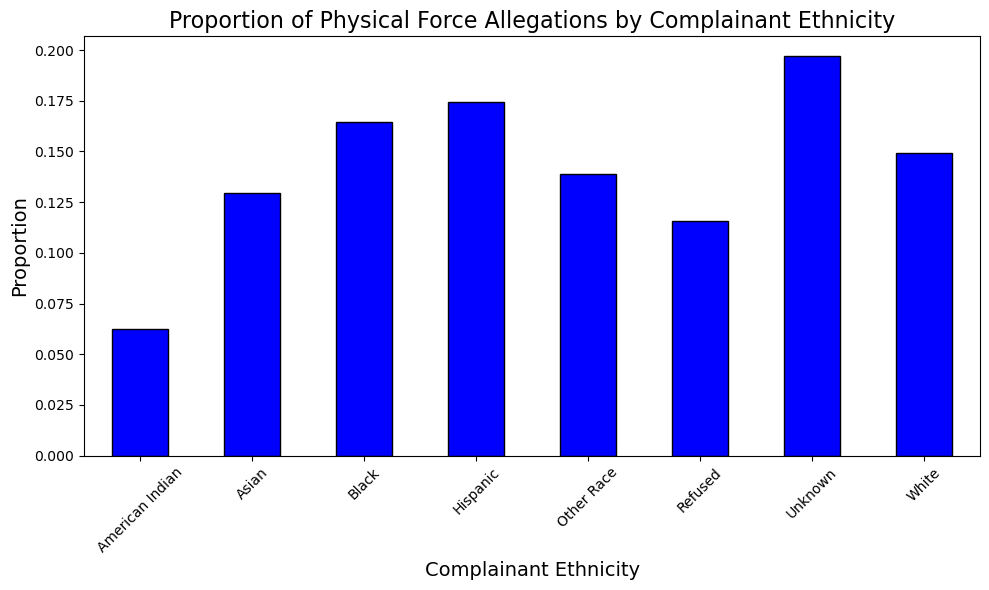

In [51]:
import matplotlib.pyplot as plt

# Calculate the proportion of 'Physical force' allegations by complainant ethnicity
police_sub = police[police['allegation'] == 'Physical force']
b = police_sub.groupby('complainant_ethnicity').size() / police.groupby('complainant_ethnicity').size()

# Create the histogram
plt.figure(figsize=(10, 6))
b.plot(kind='bar', color='blue', edgecolor='black')

# Add labels and title
plt.title('Proportion of Physical Force Allegations by Complainant Ethnicity', fontsize=16)
plt.xlabel('Complainant Ethnicity', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()